<a href="https://colab.research.google.com/github/arshadhs/aiml-bits/blob/main/2025ag05458_assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Neural Networks (DNN) - Assignment 1

**Comparing Logistic Regression and Multi-Layer Perceptron**

*Adult Census Income Dataset*

---

* Programming Assignment: Comparing Linear Models and MLPs
* Course: Deep Neural Networks
* Type: Individual Programming
* Submission: .ipynb + HTML version ( Download HTML version of the ipynb file)

**Learning Objectives**
* Understand classification fundamentals
* Implement gradient descent
* Build neural networks without high-level libraries
* Evaluate and compare models
* Analyse computational trade-offs

# Implementation

Both models are trained using **Batch Gradient Descent**, where the full training dataset is used to compute the gradients before each parameter update.

The overall **training workflow** is as follows:

1. Load and preprocess the dataset
2. Train the baseline Logistic Regression model
3. Store the loss value at each epoch
4. Train the Multi-Layer Perceptron
5. Store the loss value at each epoch
6. Evaluate both models on the test set
7. Compare classification performance and training time

## Import - Libraries

In [ ]:
import numpy as np                  # For numerical operations
import pandas as pd                 # For data manipulation
import matplotlib.pyplot as plt     # For plotting
import seaborn as sns               # For enhanced data visualization
import time                         # For measuring execution time

from sklearn.model_selection import train_test_split            # For splitting data into training and test sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder # For feature scaling and encoding


# Dataset Selection

Real world dataset: **Census Income**

*Predict whether income exceeds $50K/yr based on census data. Also known as Adult dataset*

- Dataset Name: **Adult Census Income Dataset**
- **Source**: UCI ML Repository
- **URL**: https://archive.ics.uci.edu/dataset/20/census+income
- **Task Type**: Binary Classification
- **Dataset Characteristics**: Multivariate
- **Feature Type**: Categorical and Integer
- **Instances**: 48,842 (≥ 500 samples)
- **Raw Input Features**: 14 (≥ 10 features <50 )
- **Processed Input Features**: 104 after one-hot encoding and scaling
- **Samples After Cleaning**: 30,162
- **Target Variable**: `income`
- **Target Classes**: `<=50K` and `>50K`

The dataset contains demographic, educational, and occupational information such as age, education level, occupation, marital status, hours worked per week, and native country. The features make it appropriate for comparing a linear baseline model with a neural-network-based model.

## Why this Dataset is selected

The dataset satisfies the assignment requirements because it contains more than 500 samples and more than 10 input features. It also includes both numeric and categorical variables, making preprocessing meaningful and allowing the comparison between a linear model and a neural network to be more informative.

In [ ]:
def load_database():
    '''
    Load dataset and handle missing values.
    Dataset: Adult Census Income (binary classification)
    '''

    cols = [
        "age", "workclass", "fnlwgt", "education", "education_num",
        "marital_status", "occupation", "relationship", "race", "sex",
        "capital_gain", "capital_loss", "hours_per_week", "native_country",
        "income"
    ]

    df = pd.read_csv(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
        header=None,
        names=cols,
        skipinitialspace=True,
        na_values="?"
    )

    print("=" * 50)
    print("DATASET OVERVIEW")
    print("=" * 50)
    print(f"Dataset name        : Adult Census Income")

    return df

# Data Preprocessing

The dataset is preprocessed before training so that both the **Logistic Regression** model and the **MLP** can learn effectively from the data.

The main preprocessing steps are:

- **Train-test split**
- **Missing value handling**
- **Categorical encoding**
- **Feature scaling**

More specifically:

- **Rows with missing values are removed**
- The target variable `income` is converted into binary labels: `0` and `1`
- Categorical features are transformed using **one-hot encoding**
- Numeric features are standardised using **feature scaling**
- The dataset is split into **training** and **test** sets

In [ ]:
def data_preprocessing(df):
    '''
    Data Preprocessing -
      Preprocess the data as needed for training the model.
      Train-test split (70-30/80–20/ 90–10), handle missing values, encode categorical variables,
      scale features, etc.
    '''

    # Make a copy so original dataframe is not modified
    original_rows = len(df)
    df = df.copy()

    # Handle missing values
    df = df.dropna()

    # Clean target column in case of spaces or trailing dots
    df["income"] = df["income"].astype(str).str.strip().str.replace(".", "", regex=False)

    # Map target to binary
    df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

    # Drop any rows where mapping failed
    df = df.dropna(subset=["income"])

    # Features and target
    x = df.drop("income", axis=1)
    y = df["income"].values.reshape(-1, 1)

    # Separate numeric and categorical columns
    categorical_cols = x.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = x.select_dtypes(exclude=["object"]).columns.tolist()

    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.3, random_state=42, stratify=y
    )

    # test_size: Determines the proportion of data for the test set (e.g., 0.3 for 30%). If not specified, it defaults to 0.25.
    # random_state: An integer seed (like 42 or 0) that ensures you get the exact same split every time you run the code, which is vital for reproducibility.
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

    # One-hot encode categorical features
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    x_train_cat = encoder.fit_transform(x_train[categorical_cols])
    x_test_cat = encoder.transform(x_test[categorical_cols])

    # Scale numeric features
    scaler = StandardScaler()

    # 1. Fit and transform - Training data
    # fit_transform: Calculates the mean and standard deviation of X_train and immediately applies the scaling.
    x_train_num = scaler.fit_transform(x_train[numeric_cols])

    # 2. Transform - Test data
    # transform: Uses those exact same calculations to scale the X_test.
    # This ensures model treats the test data exactly like it treated the training data.
    x_test_num = scaler.transform(x_test[numeric_cols])

    # Combine numeric and categorical features
    x_train_processed = np.hstack([x_train_num, x_train_cat])
    x_test_processed = np.hstack([x_test_num, x_test_cat])

    print("\n" + "=" * 50)
    print("PREPROCESSING SUMMARY")
    print("=" * 50)
    print("Rows before cleaning:", original_rows)
    print("Rows after cleaning:", len(df))
    print("Dropped rows:", original_rows - len(df))
    print("Categorical columns:", categorical_cols)
    print("Numeric columns:", numeric_cols)

    print("\n" + "=" * 50)
    print("TRAIN / TEST SPLIT")
    print("=" * 50)

    split_table = pd.DataFrame({
        "Dataset": [
            "Training (X)",
            "Test (X)",
            "Training (y)",
            "Test (y)",
            "Processed Training (X)",
            "Processed Test (X)"
        ],
        "Shape": [
            x_train.shape,
            x_test.shape,
            y_train.shape,
            y_test.shape,
            x_train_processed.shape,
            x_test_processed.shape
        ]
    })

    print(split_table.to_string(index=False))
    print("\nThe processed feature count increased after one-hot encoding and scaling.")

    return x_train_processed, x_test_processed, y_train, y_test

# Baseline Model - Logistic Regression

The baseline model used in this assignment is **Logistic Regression**, implemented from scratch using NumPy. This model is a linear classifier that estimates the probability of the positive class using the sigmoid activation function.

The implementation includes the following components:

- Weight initialisation
- Forward pass
- Loss computation
- Gradient computation
- Gradient descent update
- `loss_history`
- `predict()` function

Logistic Regression provides a strong and interpretable baseline for binary classification. It is computationally efficient and useful for understanding how well a simple linear decision boundary performs on the dataset.

## Mathematical Formulation

For an input vector **x**, the linear score is computed as:

**z = Wx + b**

This score is then passed through the sigmoid activation function:

**σ(z) = 1 / (1 + e⁻ᶻ)**

The sigmoid output represents the predicted probability that the sample belongs to the positive class.

The loss function used is the **binary cross-entropy loss**:

**L = - (1/m) Σ [ y log(ŷ) + (1 - y) log(1 - ŷ) ]**

The model parameters are updated using **batch gradient descent**.


In [ ]:
class LogisticRegression(object):
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.bias = None            # Initialize bias to None, will be set in train
        self.weights = None         # Initialize to None, will be set in train
        self.loss_history = []      # Loss History

    def sigmoid(self, z):
        '''
        Sigmoid activation function
        '''
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def compute_loss(self, y_true, y_pred):
        '''
        Compute the binary cross-entropy loss.
        '''
        eps = 1e-9
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        self.loss_history.append(loss)  # Loss History
        return loss

    def fit(self, X, y):
        '''
        Train the logistic regression model using gradient descent.
        '''
        print("\nTraining Logistic Regression...")

        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for epoch in range(self.epochs):

            # Forward pass
            z = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)

            # Compute and store loss for monitoring
            loss = self.compute_loss(y, y_pred)

            if epoch % 100 == 0:
                print(f"Baseline Model - Epoch {epoch:4d} | Loss: {loss:.4f}")

            # Backward pass
            dw = (1 / n_samples) * (X.T @ (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        print(f"Final Logistic Regression Loss: {self.loss_history[-1]:.4f}")

    def predict_proba(self, X):
        '''
        Predict the class probabilities for the given input data.
        '''
        z = X @ self.weights + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        '''
        Predict the class labels for the given input data.
        '''
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

# Multi-Layer Perceptron Model

The second model used in this assignment is a **Multi-Layer Perceptron (MLP)**, also implemented from scratch using NumPy. Unlike Logistic Regression, the MLP includes hidden layers and non-linear activation functions, allowing it to learn more complex patterns in the data.

The architecture used in this notebook consists of an **input layer**, **two hidden layers**, and an **output layer**. **ReLU** activation is used in the hidden layers, while **sigmoid** activation is used in the output layer for binary classification.

## Mathematical Formulation

For each hidden layer, the linear transformation is computed as:

**Z^[l] = A^[l-1]W^[l] + b^[l]**

The activation for the hidden layers is the **ReLU** function:

**ReLU(Z) = max(0, Z)**

For the output layer, **sigmoid** activation is used:

**A^[L] = σ(Z^[L])**

The loss function is again **binary cross-entropy**, and parameter updates are performed using **backpropagation with batch gradient descent**.

In [ ]:
class MultiLayerNN:
    '''
    Multi-Layer Perceptron (MLP)
    '''
    def __init__(self, architecture, learning_rate=0.01, epochs=500):
        if len(architecture) < 3:
            raise ValueError("Architecture must include at least one hidden layer, e.g. [input, hidden, output]")

        self.architecture = architecture
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.parameters = {}
        self.loss_history = []

    def initialize_parameters(self):
        '''
        Initialize the model's parameters.
        '''
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            self.parameters[f"W{l}"] = np.random.randn(
                self.architecture[l-1], self.architecture[l]
            ) * np.sqrt(2 / self.architecture[l-1])   # He init for ReLU
            self.parameters[f"b{l}"] = np.zeros((1, self.architecture[l]))

    def relu(self, Z):
        '''
        ReLU activation function
        '''
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        '''
        Derivative of the ReLU activation function
        '''
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        '''
        Sigmoid activation function
        '''
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def compute_loss(self, y_true, y_pred):
        '''
        Compute the binary cross-entropy loss.
        '''
        eps = 1e-9
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        self.loss_history.append(loss)
        return loss

    def forward_propagation(self, X):
        '''
        Perform forward propagation through the network.
        '''
        cache = {"A0": X}
        L = len(self.architecture) - 1

        for l in range(1, L):
            Z = cache[f"A{l-1}"] @ self.parameters[f"W{l}"] + self.parameters[f"b{l}"]
            A = self.relu(Z)
            cache[f"Z{l}"] = Z
            cache[f"A{l}"] = A

        ZL = cache[f"A{L-1}"] @ self.parameters[f"W{L}"] + self.parameters[f"b{L}"]
        AL = self.sigmoid(ZL)

        cache[f"Z{L}"] = ZL
        cache[f"A{L}"] = AL
        return AL, cache

    def backward_propagation(self, y, cache):
        '''
        Perform backward propagation to compute gradients.
        '''
        grads = {}
        m = y.shape[0]
        L = len(self.architecture) - 1

        dZ = cache[f"A{L}"] - y
        grads[f"dW{L}"] = (1 / m) * (cache[f"A{L-1}"].T @ dZ)
        grads[f"db{L}"] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

        for l in range(L - 1, 0, -1):
            dA = dZ @ self.parameters[f"W{l+1}"].T
            dZ = dA * self.relu_derivative(cache[f"Z{l}"])
            grads[f"dW{l}"] = (1 / m) * (cache[f"A{l-1}"].T @ dZ)
            grads[f"db{l}"] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

        return grads

    def fit(self, X, y):
        '''
         Train the MLP model using gradient descent.
        '''
        print("\nTraining Multi-Layer Perceptron...")
        self.initialize_parameters()
        L = len(self.architecture) - 1

        for epoch in range(self.epochs):
            y_pred, cache = self.forward_propagation(X)
            loss = self.compute_loss(y, y_pred)

            if epoch % 100 == 0:
                print(f"Multi-Layer Perceptron - Epoch {epoch:4d} | Loss: {loss:.4f}")

            grads = self.backward_propagation(y, cache)

            for l in range(1, L + 1):
                self.parameters[f"W{l}"] -= self.learning_rate * grads[f"dW{l}"]
                self.parameters[f"b{l}"] -= self.learning_rate * grads[f"db{l}"]

        print(f"Final Multi-Layer Perceptron Loss: {self.loss_history[-1]:.4f}")

    def predict_proba(self, X):
        '''
        Predict the class probabilities for the given input data.
        '''
        y_pred, _ = self.forward_propagation(X)
        return y_pred

    def predict(self, X, threshold=0.5):
        '''
        Predict the class labels for the given input data.
        '''
        y_pred = self.predict_proba(X)
        return (y_pred >= threshold).astype(int)

# Evaluation & Comparison

The following metrics are used to evaluate model performance:

#### 1. Accuracy
The proportion of total predictions that are correct.

#### 2. Precision
The proportion of predicted positive samples that are actually positive.

#### 3. Recall
The proportion of actual positive samples that are correctly identified.

#### 4. F1-score
The harmonic mean of Precision and Recall. This is the **primary metric** used in this assignment because it provides a more balanced measure of classification quality when class imbalance may be present.

#### 5. Training Time
The total time required to train each model, used to compare computational cost.

---

#### Why F1-score is Chosen as the Primary Metric

The income classes in the dataset are not perfectly balanced, so Accuracy alone may not fully reflect model performance. F1-score is more appropriate in this situation because it combines Precision and Recall into a single measure and provides a better indication of how well the model handles both false positives and false negatives.

In [ ]:
def accuracy_score(y_true, y_pred):
    '''
    Compute the accuracy score.
    '''
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    '''
    Compute the precision score.
    '''
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-9)

def recall_score(y_true, y_pred):
    '''
    Compute the recall score.
    '''
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-9)

def f1_score(y_true, y_pred):
    '''
    Compute the F1 score.
    '''
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return 2 * p * r / (p + r + 1e-9)

## Visualisations - Plots

The following plots summarise the behaviour of the trained models. They include:
- training loss curves
- metric comparisons
- confusion matrices

Together, the plots help explain not only which model performed better, but also how each model made its predictions.

---

### Domain-Specific Data Exploration

The following plots are based on the dataset itself rather than the trained models. They help explain patterns in:
- the income classes
- how selected input features, such as:
  - education level
  - occupation

relate to the target variable.

In [ ]:
def plot_all_results(baseline, mlp, baseline_preds, mlp_preds, y_test, df_plot):
    '''
    Plot all results.
    '''
    y_true = np.asarray(y_test).flatten()
    baseline_preds = np.asarray(baseline_preds).flatten()
    mlp_preds = np.asarray(mlp_preds).flatten()

    baseline_metrics = {
        "Accuracy": accuracy_score(y_true, baseline_preds),
        "Precision": precision_score(y_true, baseline_preds),
        "Recall": recall_score(y_true, baseline_preds),
        "F1 Score": f1_score(y_true, baseline_preds),
    }

    mlp_metrics = {
        "Accuracy": accuracy_score(y_true, mlp_preds),
        "Precision": precision_score(y_true, mlp_preds),
        "Recall": recall_score(y_true, mlp_preds),
        "F1 Score": f1_score(y_true, mlp_preds),
    }

    def make_confusion_matrix(y_true, y_pred):
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tp = np.sum((y_true == 1) & (y_pred == 1))
        return np.array([[tn, fp], [fn, tp]])

    cm_baseline = make_confusion_matrix(y_true, baseline_preds)
    cm_mlp = make_confusion_matrix(y_true, mlp_preds)

    # ==================================================
    # Figure 1: Model Evaluation Plots
    # ==================================================
    fig1 = plt.figure(figsize=(14, 10))

    # 1. Loss curves
    ax1 = fig1.add_subplot(2, 2, 1)
    ax1.plot(baseline.loss_history, linewidth=2, label="Baseline Logistic Regression")
    ax1.plot(mlp.loss_history, linewidth=2, label="MLP")
    ax1.set_title("Training Loss Curves", fontweight="600")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # 2. Metrics comparison
    ax2 = fig1.add_subplot(2, 2, 2)
    metric_names = list(baseline_metrics.keys())
    x = np.arange(len(metric_names))
    width = 0.35
    ax2.bar(x - width/2, [baseline_metrics[m] for m in metric_names], width, label="Baseline")
    ax2.bar(x + width/2, [mlp_metrics[m] for m in metric_names], width, label="MLP")
    ax2.set_xticks(x)
    ax2.set_xticklabels(metric_names)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Score")
    ax2.set_title("Classification Metrics Comparison", fontweight="600")
    ax2.grid(True, alpha=0.3, axis="y")
    ax2.legend()

    # 3. Baseline confusion matrix
    ax3 = fig1.add_subplot(2, 2, 3)
    sns.heatmap(
        cm_baseline,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=["Pred <=50K", "Pred >50K"],
        yticklabels=["Actual <=50K", "Actual >50K"],
        ax=ax3
    )
    ax3.set_title("Baseline Confusion Matrix", fontweight="600")
    ax3.set_xlabel("Predicted Label")
    ax3.set_ylabel("True Label")

    # 4. MLP confusion matrix
    ax4 = fig1.add_subplot(2, 2, 4)
    sns.heatmap(
        cm_mlp,
        annot=True,
        fmt="d",
        cmap="Greens",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=["Pred <=50K", "Pred >50K"],
        yticklabels=["Actual <=50K", "Actual >50K"],
        ax=ax4
    )
    ax4.set_title("MLP Confusion Matrix", fontweight="600")
    ax4.set_xlabel("Predicted Label")
    ax4.set_ylabel("True Label")

    plt.suptitle("Model Evaluation: Logistic Regression vs MLP", fontsize=15, fontweight="600", y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # ==================================================
    # Figure 2: Domain-Specific / Data Exploration Plots
    # ==================================================
    fig2 = plt.figure(figsize=(18, 5))

    # 1. Income class distribution
    ax5 = fig2.add_subplot(1, 3, 1)
    sns.countplot(x="income", data=df_plot, ax=ax5)
    ax5.set_title("Income Class Distribution", fontweight="600")
    ax5.set_xlabel("Income Class")
    ax5.set_ylabel("Count")
    ax5.grid(True, alpha=0.3, axis="y")

    # 2. Education vs income
    ax6 = fig2.add_subplot(1, 3, 2)
    edu_income = pd.crosstab(df_plot["education"], df_plot["income"])
    edu_income = edu_income.loc[df_plot["education"].value_counts().index]
    edu_income.plot(kind="bar", stacked=True, ax=ax6)
    ax6.set_title("Education Level vs Income", fontweight="600")
    ax6.set_xlabel("Education Level")
    ax6.set_ylabel("Count")
    ax6.tick_params(axis="x", rotation=45)
    ax6.legend(title="Income")

    # 3. Occupation vs income
    ax7 = fig2.add_subplot(1, 3, 3)
    occ_income = pd.crosstab(df_plot["occupation"], df_plot["income"])
    occ_income = occ_income.loc[df_plot["occupation"].value_counts().index]
    occ_income.plot(kind="bar", stacked=True, ax=ax7)
    ax7.set_title("Occupation vs Income", fontweight="600")
    ax7.set_xlabel("Occupation")
    ax7.set_ylabel("Count")
    ax7.tick_params(axis="x", rotation=45)
    ax7.legend(title="Income")

    plt.suptitle("Domain-Specific Data Exploration Plots", fontsize=15, fontweight="600", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
def get_assignment_results(y_test,
                           baseline_preds, mlp_preds,
                           baseline_time, mlp_time,
                           architecture,
                           n_samples=None,
                           n_processed_features=None, n_features=None):
    return {
        "dataset_name": "Adult Census Income",
        "n_samples": int(n_samples) if n_samples is not None else None,
        "n_features": int(n_features) if n_features is not None else None,
        "n_processed_features": int(n_processed_features) if n_processed_features is not None else None,
        "problem_type": "Binary Classification",
        "primary_metric": "F1 Score",
        "baseline_model": {
            "model_name": "Logistic Regression",
            "accuracy": float(accuracy_score(y_test, baseline_preds)),
            "precision": float(precision_score(y_test, baseline_preds)),
            "recall": float(recall_score(y_test, baseline_preds)),
            "f1": float(f1_score(y_test, baseline_preds)),
            "training_time": float(baseline_time)
        },
        "mlp_model": {
            "model_name": "MLP",
            "architecture": architecture,
            "accuracy": float(accuracy_score(y_test, mlp_preds)),
            "precision": float(precision_score(y_test, mlp_preds)),
            "recall": float(recall_score(y_test, mlp_preds)),
            "f1": float(f1_score(y_test, mlp_preds)),
            "training_time": float(mlp_time)
        }
    }

# Main Execution

In [ ]:
def main():
    '''
    Main execution function.
    '''
    print("=" * 60)
    print("DEEP NEURAL NETWORKS ASSIGNMENT - 1")
    print("Comparing Logistic Regression and MLP")
    print("=" * 60)

    df = load_database()

    input_features = df.drop("income", axis=1).columns.tolist()

    print(f"Dataset shape: {df.shape}")
    print("Input features:", len(input_features))
    print("Feature names:", input_features)
    print("Target column: income")

    x_train_s, x_test_s, y_train, y_test = data_preprocessing(df)

    #print("\n[2] PREPROCESSING COMPLETED")

    # Baseline Model: Logistic Regression
    baseline = LogisticRegression(learning_rate=0.05, epochs=1000)

    print("\n" + "=" * 50)
    print("BASELINE LOGISTIC REGRESSION - TRAINING...")
    print("=" * 50)

    #print("\n[3] TRAINING BASELINE LOGISTIC REGRESSION...")
    start = time.time()
    baseline.fit(x_train_s, y_train)
    baseline_time = time.time() - start

    baseline_preds = baseline.predict(x_test_s).flatten()

    # MLP Model
    architecture = [x_train_s.shape[1], 32, 16, 1]
    mlp = MultiLayerNN(
        architecture=architecture,
        learning_rate=0.05,
        epochs=1000
    )

    print("\n" + "=" * 50)
    print("MULTI-LAYER PERCEPTRON - TRAINING...")
    print("=" * 50)

    #print("\n[4] TRAINING MLP...")
    start = time.time()
    mlp.fit(x_train_s, y_train)
    mlp_time = time.time() - start

    mlp_preds = mlp.predict(x_test_s).flatten()

    cleaned_samples = x_train_s.shape[0] + x_test_s.shape[0]

    results = get_assignment_results(
        y_test,
        baseline_preds, mlp_preds,
        baseline_time, mlp_time,
        mlp.architecture,
        n_samples=cleaned_samples,
        n_processed_features=x_test_s.shape[1],
        n_features=len(input_features)
    )

    print("\n" + "=" * 60)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("=" * 60)

    print(f"Dataset Name        : {results['dataset_name']}")
    print(f"Samples             : {results['n_samples']}")
    print(f"Raw Features        : {results['n_features']}")
    print(f"Processed Features  : {results['n_processed_features']}")
    print(f"Problem Type        : {results['problem_type']}")
    print(f"Primary Metric      : {results['primary_metric']}")

    print("\n" + "-" * 60)
    print("BASELINE MODEL")
    print("-" * 60)
    print(f"Model Name     : {results['baseline_model']['model_name']}")
    print(f"Accuracy       : {results['baseline_model']['accuracy']:.4f}")
    print(f"Precision      : {results['baseline_model']['precision']:.4f}")
    print(f"Recall         : {results['baseline_model']['recall']:.4f}")
    print(f"F1 Score       : {results['baseline_model']['f1']:.4f}")
    print(f"Training Time  : {results['baseline_model']['training_time']:.2f} seconds")

    print("\n" + "-" * 60)
    print("MLP MODEL")
    print("-" * 60)
    print(f"Model Name     : {results['mlp_model']['model_name']}")
    arch = results['mlp_model']['architecture']
    print(f"Architecture   : Input ({arch[0]}) → Hidden 1 ({arch[1]}) → Hidden 2 ({arch[2]}) → Output ({arch[3]})")
    print(f"Accuracy       : {results['mlp_model']['accuracy']:.4f}")
    print(f"Precision      : {results['mlp_model']['precision']:.4f}")
    print(f"Recall         : {results['mlp_model']['recall']:.4f}")
    print(f"F1 Score       : {results['mlp_model']['f1']:.4f}")
    print(f"Training Time  : {results['mlp_model']['training_time']:.2f} seconds")

    print("\n" + "-" * 60)
    print("MODEL COMPARISON")
    print("-" * 60)

    f1_diff = results['mlp_model']['f1'] - results['baseline_model']['f1']
    acc_diff = results['mlp_model']['accuracy'] - results['baseline_model']['accuracy']
    time_diff = results['mlp_model']['training_time'] - results['baseline_model']['training_time']

    print(f"Accuracy Improvement : {acc_diff:.4f}")
    print(f"F1 Improvement       : {f1_diff:.4f}")
    print(f"Extra Training Time  : {time_diff:.2f} seconds")

    # Plot results
    df_plot = df.dropna().copy()
    plot_all_results(baseline, mlp, baseline_preds, mlp_preds, y_test, df_plot)

DEEP NEURAL NETWORKS ASSIGNMENT - 1
Comparing Logistic Regression and MLP
DATASET OVERVIEW
Dataset name        : Adult Census Income
Dataset shape: (32561, 15)
Input features: 14
Feature names: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']
Target column: income

PREPROCESSING SUMMARY
Rows before cleaning: 32561
Rows after cleaning: 30162
Dropped rows: 2399
Categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Numeric columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

TRAIN / TEST SPLIT
               Dataset        Shape
          Training (X)  (21113, 14)
              Test (X)   (9049, 14)
          Training (y)   (21113, 1)
              Test (y)    (9049, 1)
Processed Training (X) (21113, 104)
    Processed Test (X)  (904

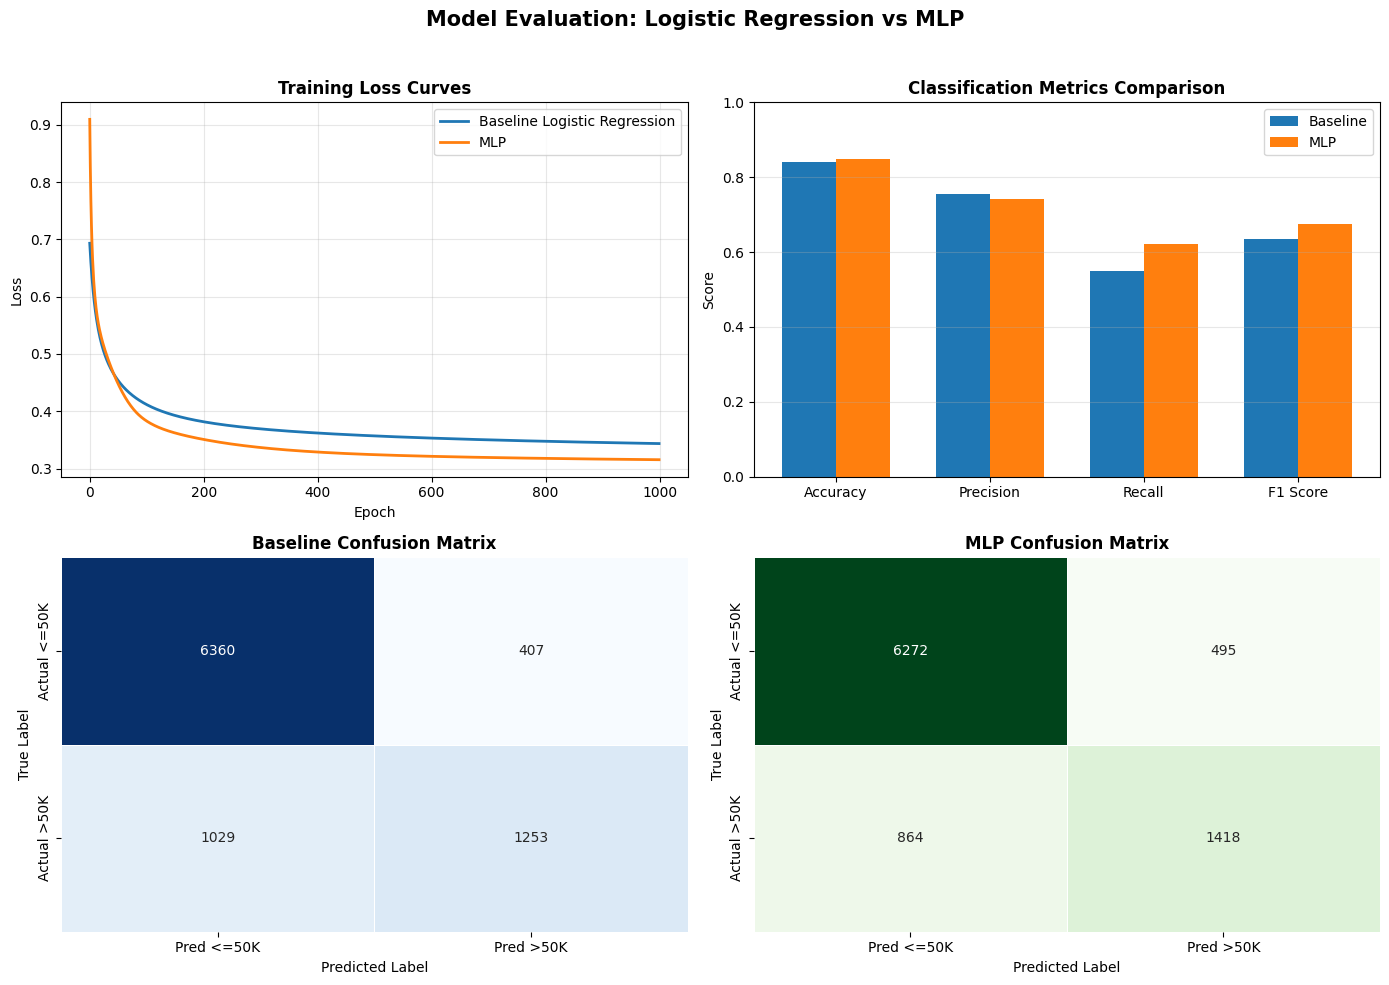

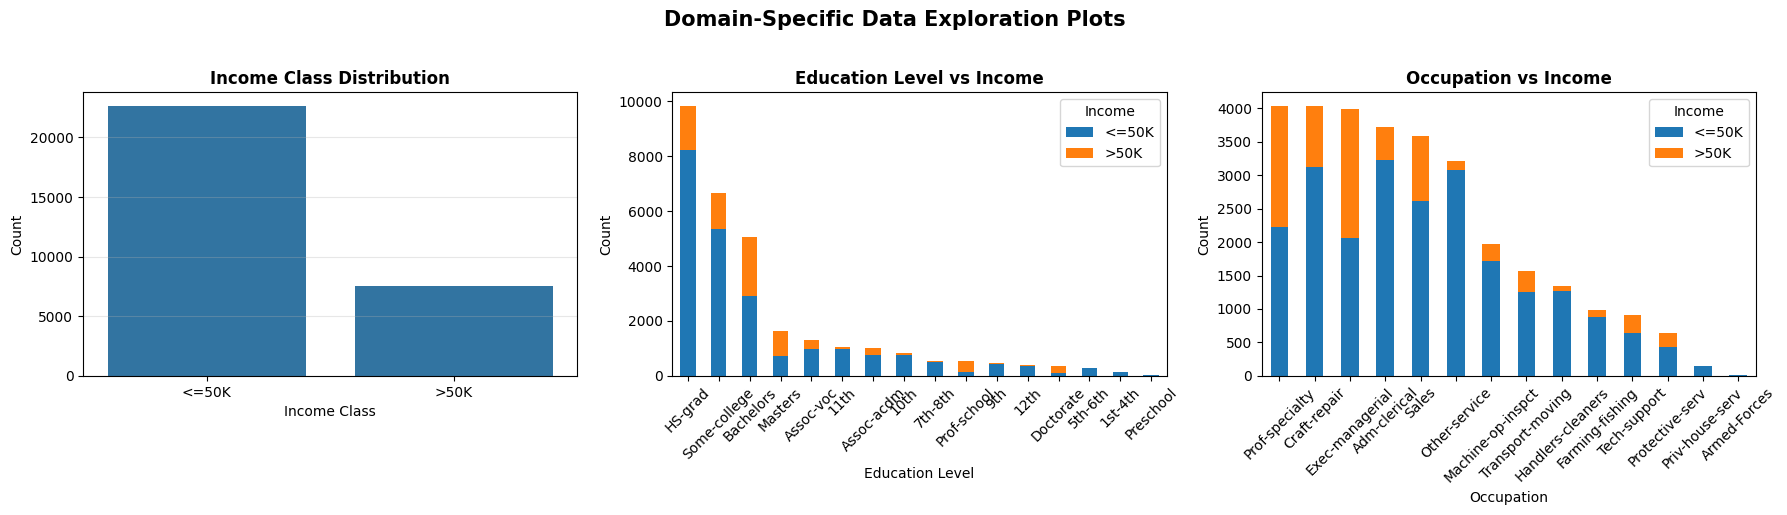

In [ ]:
if __name__ == '__main__':
    main()

# Analysis

1. **Better Performance**: The **MLP** outperformed Logistic Regression with higher **Accuracy (≈ 0.8382)** and **F1-score (≈ 0.6374)** vs **0.8248** and **0.5615**, showing improved handling of class imbalance.

2. **Efficiency vs Accuracy**: **Logistic Regression** trained quickly (**12.16s**) and achieved higher **Precision (0.7614)**, but lower **Recall (0.4448)** means it missed more positive cases.

3. **Trade-off**:
   - Logistic Regression: precise but conservative  
   - MLP: higher recall (**0.5640**), better detection of high-income cases  

4. **Model Capability**: The MLP captured more complex patterns, with lower loss (**0.3507**) vs Logistic Regression (**0.3818**).

5. **Computational Cost**: The MLP took **65.80s (~5× slower)**, highlighting increased complexity.

### Key Insights

- **F1-score is important** for imbalanced data  
- **Logistic Regression is fast and interpretable**  
- **MLP improves overall performance and balance**  
- **Better results require more computation**

Overall, the results highlight a trade-off between **efficiency and predictive performance**. Logistic Regression is fast and interpretable, while the MLP delivers stronger, more balanced classification performance.